<a href="https://colab.research.google.com/github/1WA23CS034/Machine-Learning/blob/main/ML_lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

lab 5 - Decision Trees


In [ ]:
import pandas as pd
df1=pd.read_csv("iris.csv")
df1

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### 1. Decision Tree Classifier for Iris Dataset

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

X_iris = df1[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_iris = df1['species']

# Split data into training and testing sets (80% train, 20% test)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Build and train the Decision Tree classifier
dtc_iris = DecisionTreeClassifier(random_state=42)
dtc_iris.fit(X_train_iris, y_train_iris)


y_pred_iris = dtc_iris.predict(X_test_iris)


accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
print(f"Accuracy Score for Iris Dataset: {accuracy_iris:.4f}")


conf_matrix_iris = confusion_matrix(y_test_iris, y_pred_iris)
print("\nConfusion Matrix for Iris Dataset:")
print(conf_matrix_iris)

Accuracy Score for Iris Dataset: 1.0000

Confusion Matrix for Iris Dataset:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### 2. Decision Tree Classifier for Drug Dataset

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_drug = df2.drop('Drug', axis=1)
y_drug = df2['Drug']

le = LabelEncoder()

X_drug['Sex'] = le.fit_transform(X_drug['Sex'])
X_drug['BP'] = le.fit_transform(X_drug['BP'])
X_drug['Cholesterol'] = le.fit_transform(X_drug['Cholesterol'])

# Split data into training and testing sets (80% train, 20% test)
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug, y_drug, test_size=0.2, random_state=42)

# Build and train the Decision Tree classifier
dtc_drug = DecisionTreeClassifier(random_state=42)
dtc_drug.fit(X_train_drug, y_train_drug)

y_pred_drug = dtc_drug.predict(X_test_drug)

accuracy_drug = accuracy_score(y_test_drug, y_pred_drug)
print(f"Accuracy Score for Drug Dataset: {accuracy_drug:.4f}")

conf_matrix_drug = confusion_matrix(y_test_drug, y_pred_drug)
print("\nConfusion Matrix for Drug Dataset:")
print(conf_matrix_drug)

Accuracy Score for Drug Dataset: 1.0000

Confusion Matrix for Drug Dataset:
[[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


In [ ]:
df2=pd.read_csv("drug.csv")
df2


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
df3=pd.read_csv("petrol_consumption.csv")
df3.head(10)

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410
5,10.0,5342,1333,0.571,457
6,8.0,5319,11868,0.451,344
7,8.0,5126,2138,0.553,467
8,8.0,4447,8577,0.529,464
9,7.0,4512,8507,0.552,498


### Analyzing Regression Tree for Petrol Consumption

Feature Importances for Petrol Consumption Regression Tree:
                        Feature  Importance
3  Population_Driver_licence(%)    0.651569
1                Average_income    0.240522
0                    Petrol_tax    0.065750
2                Paved_Highways    0.042160


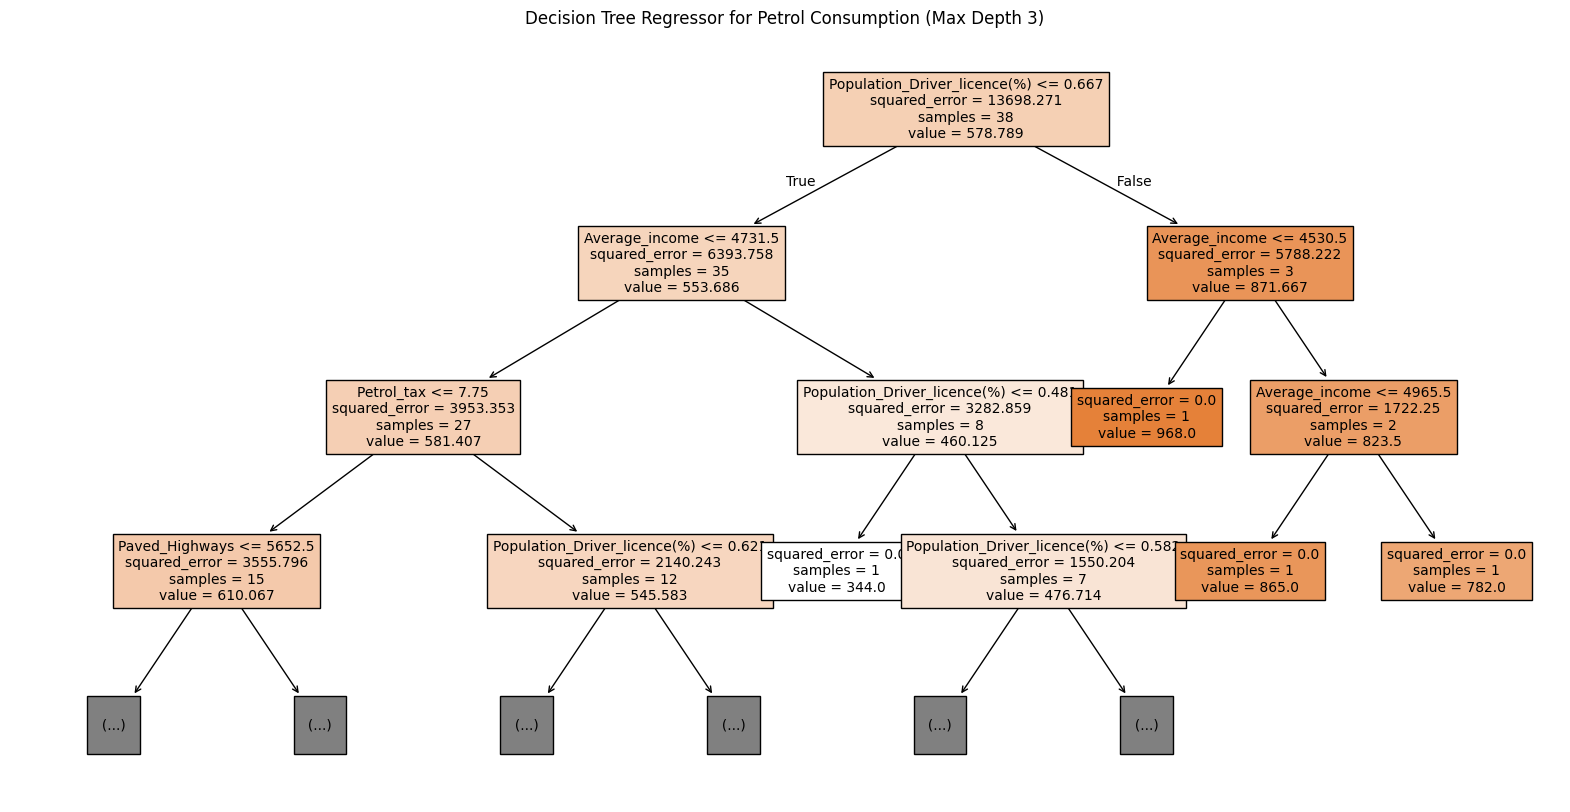

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_importances = dtr_petrol.feature_importances_
features = X_petrol.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances for Petrol Consumption Regression Tree:")
print(importance_df)

# Visualize the Decision Tree Regressor
plt.figure(figsize=(20,10))
plot_tree(dtr_petrol, filled=True, feature_names=features, max_depth=3, fontsize=10)
plt.title("Decision Tree Regressor for Petrol Consumption (Max Depth 3)")
plt.show()

### 3. Regression Tree for Petrol Consumption Dataset

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

X_petrol = df3.drop('Petrol_Consumption', axis=1)
y_petrol = df3['Petrol_Consumption']

# Split data into training and testing sets (80% train, 20% test)
X_train_petrol, X_test_petrol, y_train_petrol, y_test_petrol = train_test_split(X_petrol, y_petrol, test_size=0.2, random_state=42)

# Build and train the Decision Tree Regressor
dtr_petrol = DecisionTreeRegressor(random_state=42)
dtr_petrol.fit(X_train_petrol, y_train_petrol)

y_pred_petrol = dtr_petrol.predict(X_test_petrol)

mae_petrol = mean_absolute_error(y_test_petrol, y_pred_petrol)
mse_petrol = mean_squared_error(y_test_petrol, y_pred_petrol)
rmse_petrol = np.sqrt(mse_petrol)

print(f"\n--- Regression Tree for Petrol Consumption ---")
print(f"Mean Absolute Error (MAE): {mae_petrol:.4f}")
print(f"Mean Squared Error (MSE): {mse_petrol:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_petrol:.4f}")


--- Regression Tree for Petrol Consumption ---
Mean Absolute Error (MAE): 94.3000
Mean Squared Error (MSE): 17347.7000
Root Mean Squared Error (RMSE): 131.7107


In [ ]:
import math

a0 = -5
a1 = 0.8
study_hours = 7
threshold = 0.5

print("--- Problem 1: Logistic Regression ---")

print(f"a. Logistic Regression Equation: P(pass) = 1 / (1 + e^(-({a0} + {a1} * study_hours)))")
print(f"Or, P(pass) = 1 / (1 + e^({-a0} - {a1} * study_hours))")

z = a0 + a1 * study_hours
prob_pass = 1 / (1 + math.exp(-z))
print(f"\nb. For study hours = {study_hours}:")
print(f"   Linear combination (z): {z:.4f}")
print(f"   Probability of passing: {prob_pass:.4f}")

predicted_class = "Pass" if prob_pass >= threshold else "Fail"
print(f"\nc. Predicted class (threshold={threshold}): {predicted_class}")

print("\n--- Problem 2: SoftMax Function ---")

z_values = [2, 1, 0]

exp_z = [math.exp(val) for val in z_values]

sum_exp_z = sum(exp_z)

probabilities = [exp_val / sum_exp_z for exp_val in exp_z]

print(f"Given z values: {z_values}")
print(f"Exponential values (e^z): {exp_z}")
print(f"Sum of exponential values: {sum_exp_z:.4f}")
print("Probability values:")
for i, p in enumerate(probabilities):
    print(f"  P(class {i+1}): {p:.4f}")

--- Problem 1: Logistic Regression ---
a. Logistic Regression Equation: P(pass) = 1 / (1 + e^(-(-5 + 0.8 * study_hours)))
Or, P(pass) = 1 / (1 + e^(5 - 0.8 * study_hours))

b. For study hours = 7:
   Linear combination (z): 0.6000
   Probability of passing: 0.6457

c. Predicted class (threshold=0.5): Pass

--- Problem 2: SoftMax Function ---
Given z values: [2, 1, 0]
Exponential values (e^z): [7.38905609893065, 2.718281828459045, 1.0]
Sum of exponential values: 11.1073
Probability values:
  P(class 1): 0.6652
  P(class 2): 0.2447
  P(class 3): 0.0900


1. For “iris.csv” dataset:
Accuracy Score: The accuracy score for the IRIS dataset was 1.0000.
Confusion Matrix Interpretation: The confusion matrix was:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
This confusion matrix indicates perfect classification. All 10 instances of the first class (likely Iris-setosa), 9 instances of the second class (likely Iris-versicolor), and 11 instances of the third class (likely Iris-virginica) in the test set were correctly predicted. There were no misclassifications, and thus, no classes were confused.
2. For “petrol_consumption.csv” dataset:
Interpretation of Regression Tree Structure and Most Important Features: The most important features for predicting petrol consumption, in descending order of importance, were:

Population_Driver_licence(%): 0.6516
Average_income: 0.2405
Petrol_tax: 0.0658
Paved_Highways: 0.0422
This shows that 'Population_Driver_licence(%)' is the dominant factor influencing petrol consumption predictions, followed by 'Average_income'. The Regression Tree makes its primary splits based on these features.

How Regression Tree handles continuous target variables compared to Decision Tree classifier: A Decision Tree Classifier is designed for classification tasks, where the target variable is categorical (discrete classes). It assigns a class label to each leaf node, typically the majority class of the samples in that node.

A Regression Tree, on the other hand, is designed for regression tasks, where the target variable is continuous (numerical values). Instead of a class label, each leaf node of a regression tree holds a predicted numerical value, which is typically the average (or median) of the target values of all training samples that fall into that specific leaf.